# 08_cluster_visualization

This notebook visualizes ASRS incident clusters using dimensionality reduction
(UMAP and t-SNE). Each point represents an incident, colored by cluster assignment,
with optional overlays for risk score and HFACS levels.

These visualizations help reveal structure, themes, and relationships across
16,535 aviation safety narratives.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
import umap.umap_ as umap

In [3]:
df = pd.read_csv("../data/processed/asrs_clustered_3yrs.csv")

print("Loaded:", df.shape)
df[["cluster", "cluster_terms"]].head()


C:\Users\jenny\AppData\Local\Temp\ipykernel_16228\263129187.py:1: DtypeWarning: Columns (7,8,15,19,20,38,39,40,41,42,43,44,45,46,47,48,49,50,59,63,78,79,81,82,83,86,89,99,100,110,111,123) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/asrs_clustered_3yrs.csv")


Loaded: (16535, 140)


,cluster,cluster_terms
0,5,"aircraft, traffic, airspace, ft, controller, s..."
1,1,"aircraft, flight, maintenance, zzz, crew, land..."
2,1,"aircraft, flight, maintenance, zzz, crew, land..."
3,1,"aircraft, flight, maintenance, zzz, crew, land..."
4,1,"aircraft, flight, maintenance, zzz, crew, land..."


In [5]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = text.replace("\n", " ")
    return text

df["clean_narrative"] = df["Narrative"].apply(clean_text)

# extra safety
df["clean_narrative"] = df["clean_narrative"].fillna("").astype(str)
df["clean_narrative"].head()

0    to be clear i did not have a lot going on and ...
1    while descending into pib out of 14;000 ft. ms...
2    i was boarding the aircraft when a my destinat...
3    i had a ferry flight that went out of service ...
4    we were flying at 2500 ft. i started losing el...
Name: clean_narrative, dtype: object

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df["clean_narrative"])
X.shape

(16535, 5000)

In [7]:
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

umap_embedding = umap_model.fit_transform(X)
df["umap_x"] = umap_embedding[:, 0]
df["umap_y"] = umap_embedding[:, 1]

C:\Users\jenny\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [9]:
tsne_model = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate=200,
    random_state=42,
    max_iter=1500    # replaces n_iter
)

tsne_embedding = tsne_model.fit_transform(X.toarray())
df["tsne_x"] = tsne_embedding[:, 0]
df["tsne_y"] = tsne_embedding[:, 1]

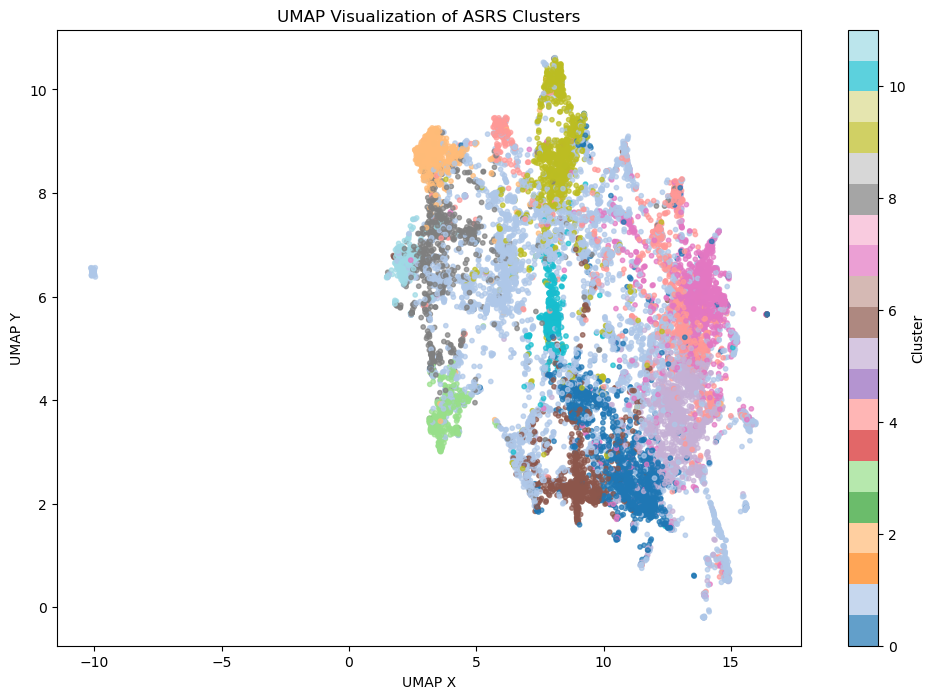

In [10]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df["umap_x"], df["umap_y"],
    c=df["cluster"],
    cmap="tab20",
    s=10,
    alpha=0.7
)

plt.title("UMAP Visualization of ASRS Clusters")
plt.xlabel("UMAP X")
plt.ylabel("UMAP Y")
plt.colorbar(scatter, label="Cluster")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'images/tsne_clusters.png'

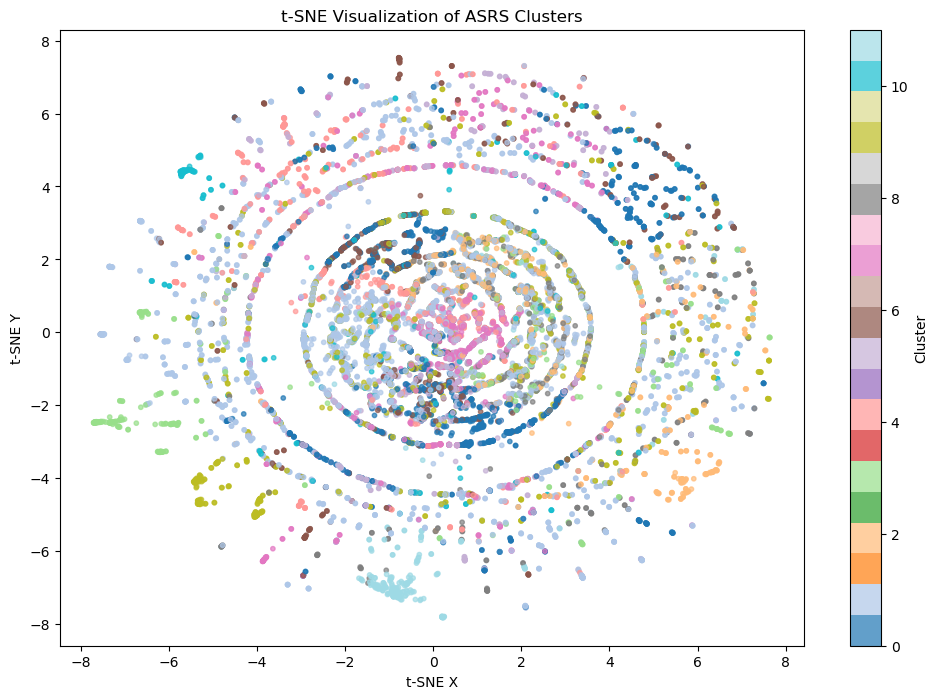

In [13]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df["tsne_x"], df["tsne_y"],
    c=df["cluster"],
    cmap="tab20",
    s=10,
    alpha=0.7
)

plt.title("t-SNE Visualization of ASRS Clusters")
plt.xlabel("t-SNE X")
plt.ylabel("t-SNE Y")
plt.colorbar(scatter, label="Cluster")

# Save the figure
plt.savefig("images/tsne_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

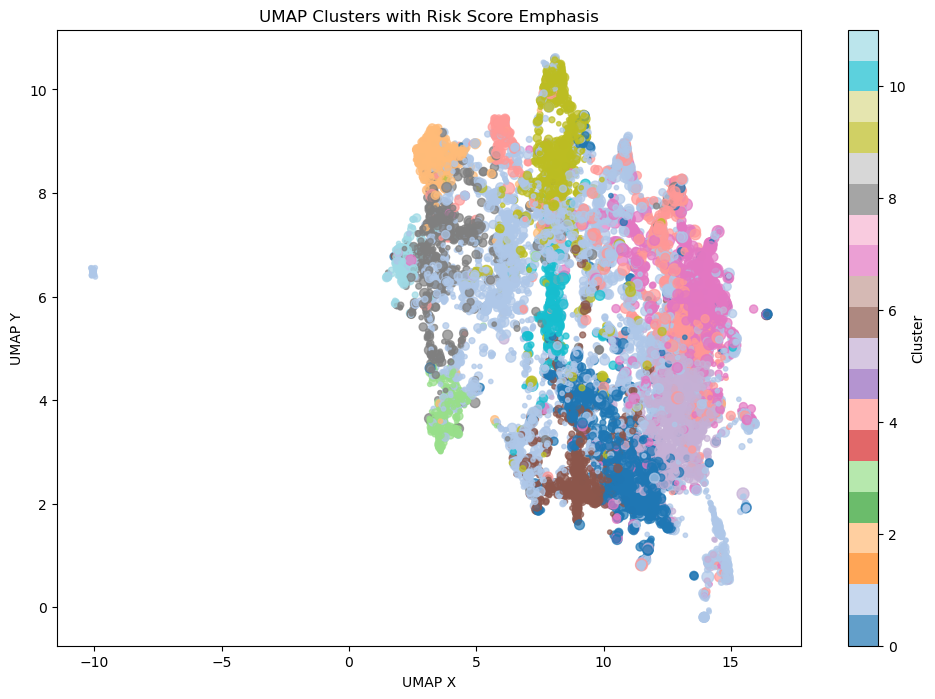

In [12]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df["umap_x"], df["umap_y"],
    c=df["cluster"],
    cmap="tab20",
    s=df["risk_score"] * 8 + 10,
    alpha=0.7
)

plt.title("UMAP Clusters with Risk Score Emphasis")
plt.xlabel("UMAP X")
plt.ylabel("UMAP Y")
plt.colorbar(scatter, label="Cluster")
plt.show()

In [ ]:
output_file = "../data/processed/asrs_cluster_visualized_3yrs.csv"
df.to_csv(output_file, index=False)

print("Saved:", output_file)
print("Final shape:", df.shape)